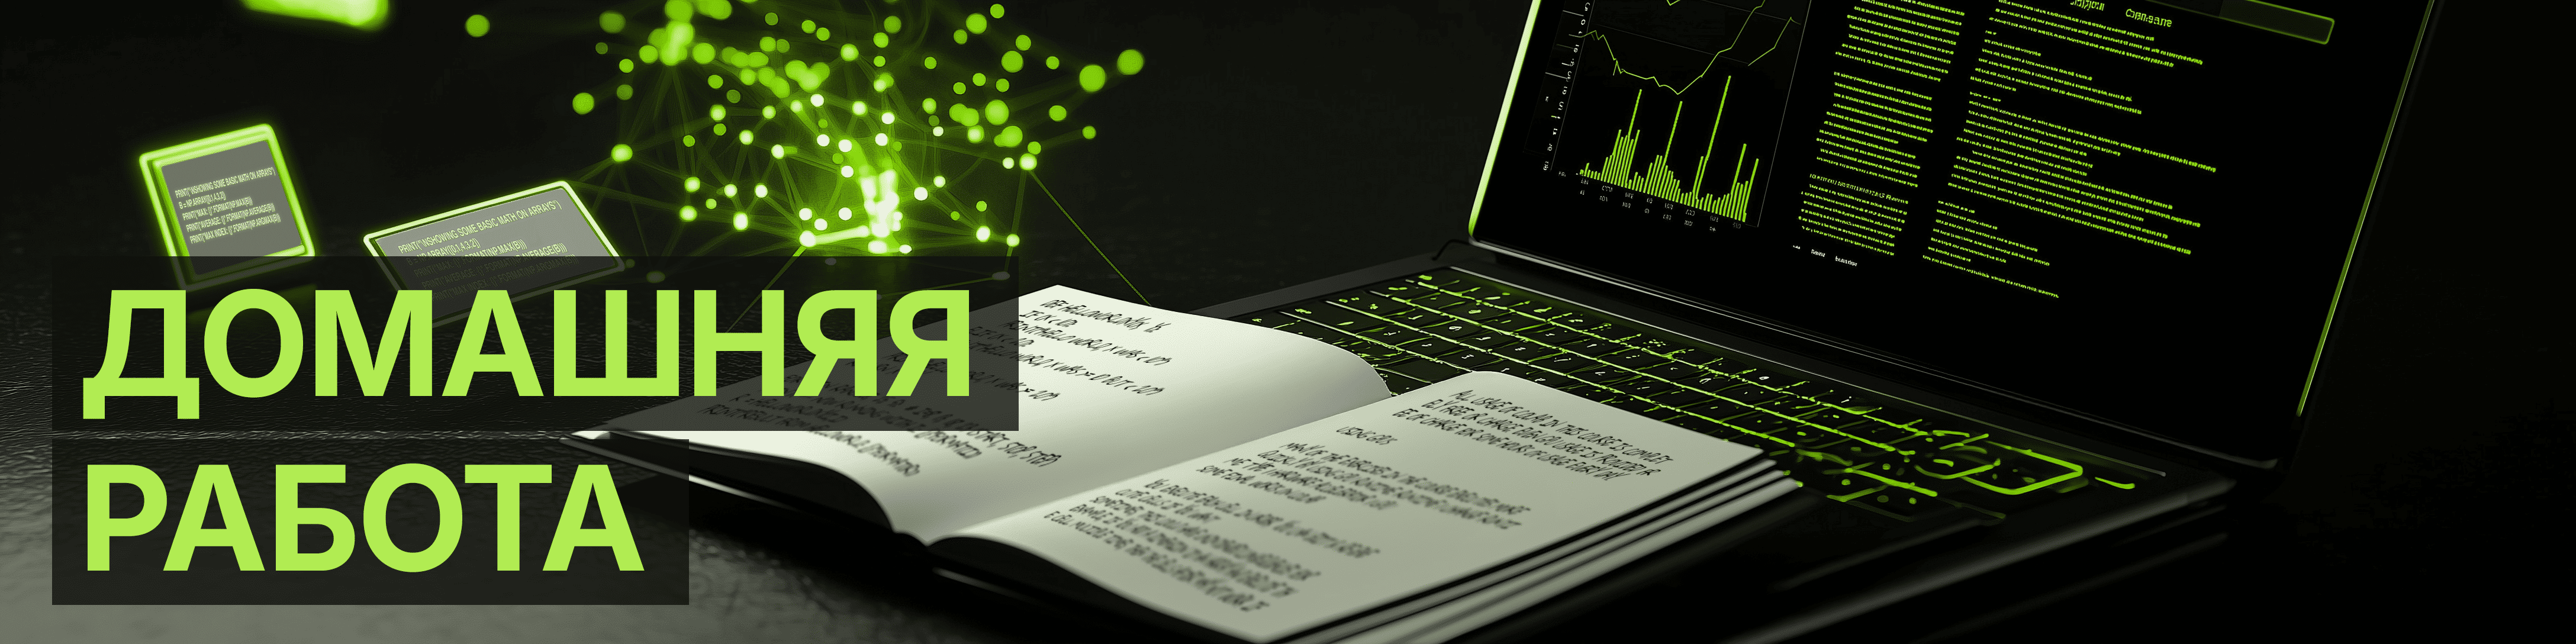

**Навигация по уроку**
1. [Архитектура автокодировщиков](https://colab.research.google.com/drive/1su5Dlu7SlFzmWlEw_Ix5q5Ps6PicwRND)
2. [Обнаружение выбросов и аномалий](https://colab.research.google.com/drive/1oLBwktGpPIqt8YLygBR1H45rdqw4sZdh)
3. [Удаление водяных знаков с помощью сверточных автокодировщиков](https://colab.research.google.com/drive/1L00DEOKX5yuHlHY0VhxBo3sGSWsjnJsB)
4. Домашняя работа

В домашней работе вам необходимо выполнить одно из трёх заданий на выбор:


**Задание 1. На 3 балла:**

1. Ваша задача научить автокодировщик очищать шум на изображениях.

2. Используйте датасет MNIST Fashion:

```python
 keras.datasets.fashion_mnist.load_data()
```

3. В процессе обучения, на вход необходимо подавать изображения с шумом, на выход без шума.

4. Сгенерируйте шум:

```python
# генерируем тензор случайных значения равный по форме наших данным
train_noise = np.random.standard_normal(y_train.shape)/30 + .5
test_noise = np.random.standard_normal(y_test.shape)/30 + .5
```

5. Создайте зашумленные изображения:

```python
X_train = y_train + train_noise
X_test = y_test + test_noise
```
6. Подумайте над архитектурой автокодировщика.

7. Обучите модель и сделайте предсказания на контрольной выборке.

8. Продемонстрируйте работу модели путём вывода не менее 5 примеров из тестовой выборки, содержащих: исходное изображение, зашумленное изображение, предсказанное изображение и изображение шума (полученное путём вычитания предсказанного изображения из зашумленного изображения).

**Задание 2. На 4 балла:**
1. Используйте  изображения без водяных знаков из 3-й части урока (https://storage.yandexcloud.net/academy.ai/watermarked.zip)

2. Придумайте механизм нанесения водяных знаков (может быть обычный текст) на изображения. Нанесите водяные знаки на входные изображения.

3. Подумайте над архитектурой автокодировщика.

4. Размер картинок, число образцов для обучения выбирайте, исходя из ограничения среды выполнения, например,
ограничения ОЗУ бесплатного колаба.

5. Обучите модель и сделайте предсказания на контрольной выборке.

6. Продемонстрируйте работу модели путём вывода не менее 10 примеров из тестовой выборки, содержащих: исходное изображение, изображение с водяными знаками, предсказанное изображение и изображение шума (полученное путём вычитания предсказанного изображения из изображения).

**Задание 3. На 5 баллов необходимо выполнить Задание 2 со следующими улучшениями:**
1. Применить аугментацию к изображениям, не менее 5-ти модификаций (трансформаций) картинок.
2. Проведите пошаговое обучение (не менее 3-х шагов). Обучайте модель в несколько итерации: загрузили часть данных, обучили на них, почистили ОЗУ, при необходимости скорректировали параметры обучения. Это позволит использовать оперативную память более эффективно и достигнуть лучшего обучения модели.

TensorFlow: 2.20.0
Датасет загружен.
Train: watermarked/wm-nowm/train/no-watermark
Valid: watermarked/wm-nowm/valid/no-watermark
Train существует: True
Valid существует: True
Обучающих изображений: 12477
Контрольных изображений: 3289
Используем для обучения: 600
Используем для проверки: 80


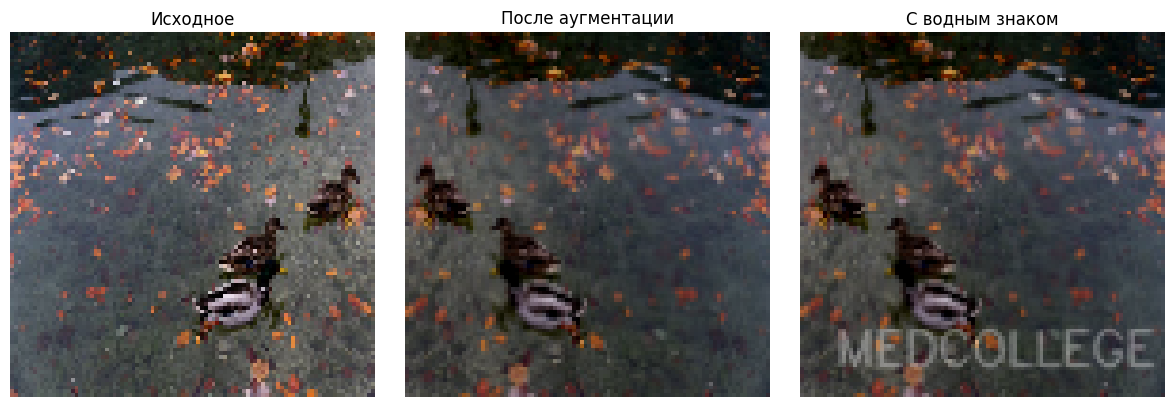

Model: "watermark_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (MaxPooling2D)     │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 48, 48, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 96, 96, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 335,107 (1.28 MB)

 Trainable params: 334,531 (1.28 MB)

 Non-trainable params: 576 (2.25 KB)

Этап 1: 200 изображений
Этап 2: 200 изображений
Этап 3: 200 изображений

Этап 1 из 3
Изображений: 200
Learning rate: 0.001
Epoch 1/4
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - loss: 0.0314 - mae: 0.1314 - val_loss: 0.0724 - val_mae: 0.2319
Epoch 2/4
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0213 - mae: 0.1114 - val_loss: 0.0644 - val_mae: 0.2163
Epoch 3/4
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0196 - mae: 0.1055 - val_loss: 0.0684 - val_mae: 0.2222
Epoch 4/4
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0157 - mae: 0.0927 - val_loss: 0.0631 - val_mae: 0.2200
Этап 1 завершен.

Этап 2 из 3
Изображений: 200
Learning rate: 0.0005
Epoch 1/4
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0163 - mae: 0.0957 - val_loss: 0.0593 - val_mae: 0.2110
Epoch 2/4
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0162 - mae: 0.0965 - val_loss: 0.0581 - val_mae: 0.2102
Epoch 3/4
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0165 - mae: 0.0956 - val_loss: 0.0521 - val_mae: 0

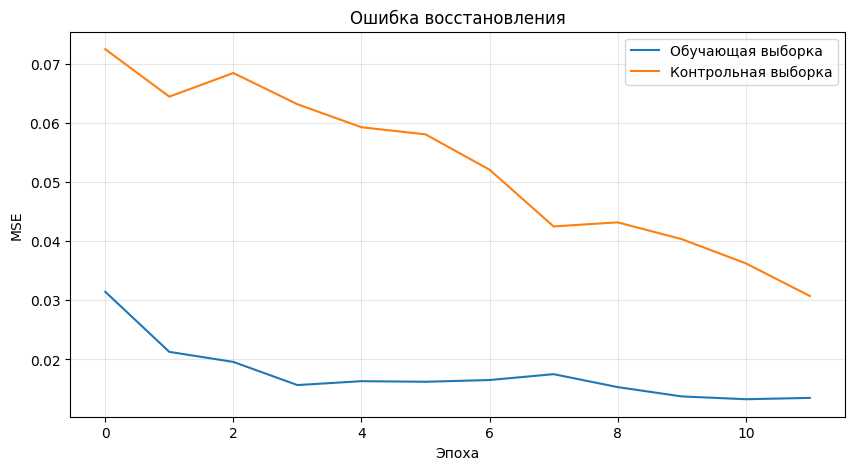

Тестовых изображений: 10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
MSE: 0.031543
MAE: 0.146778


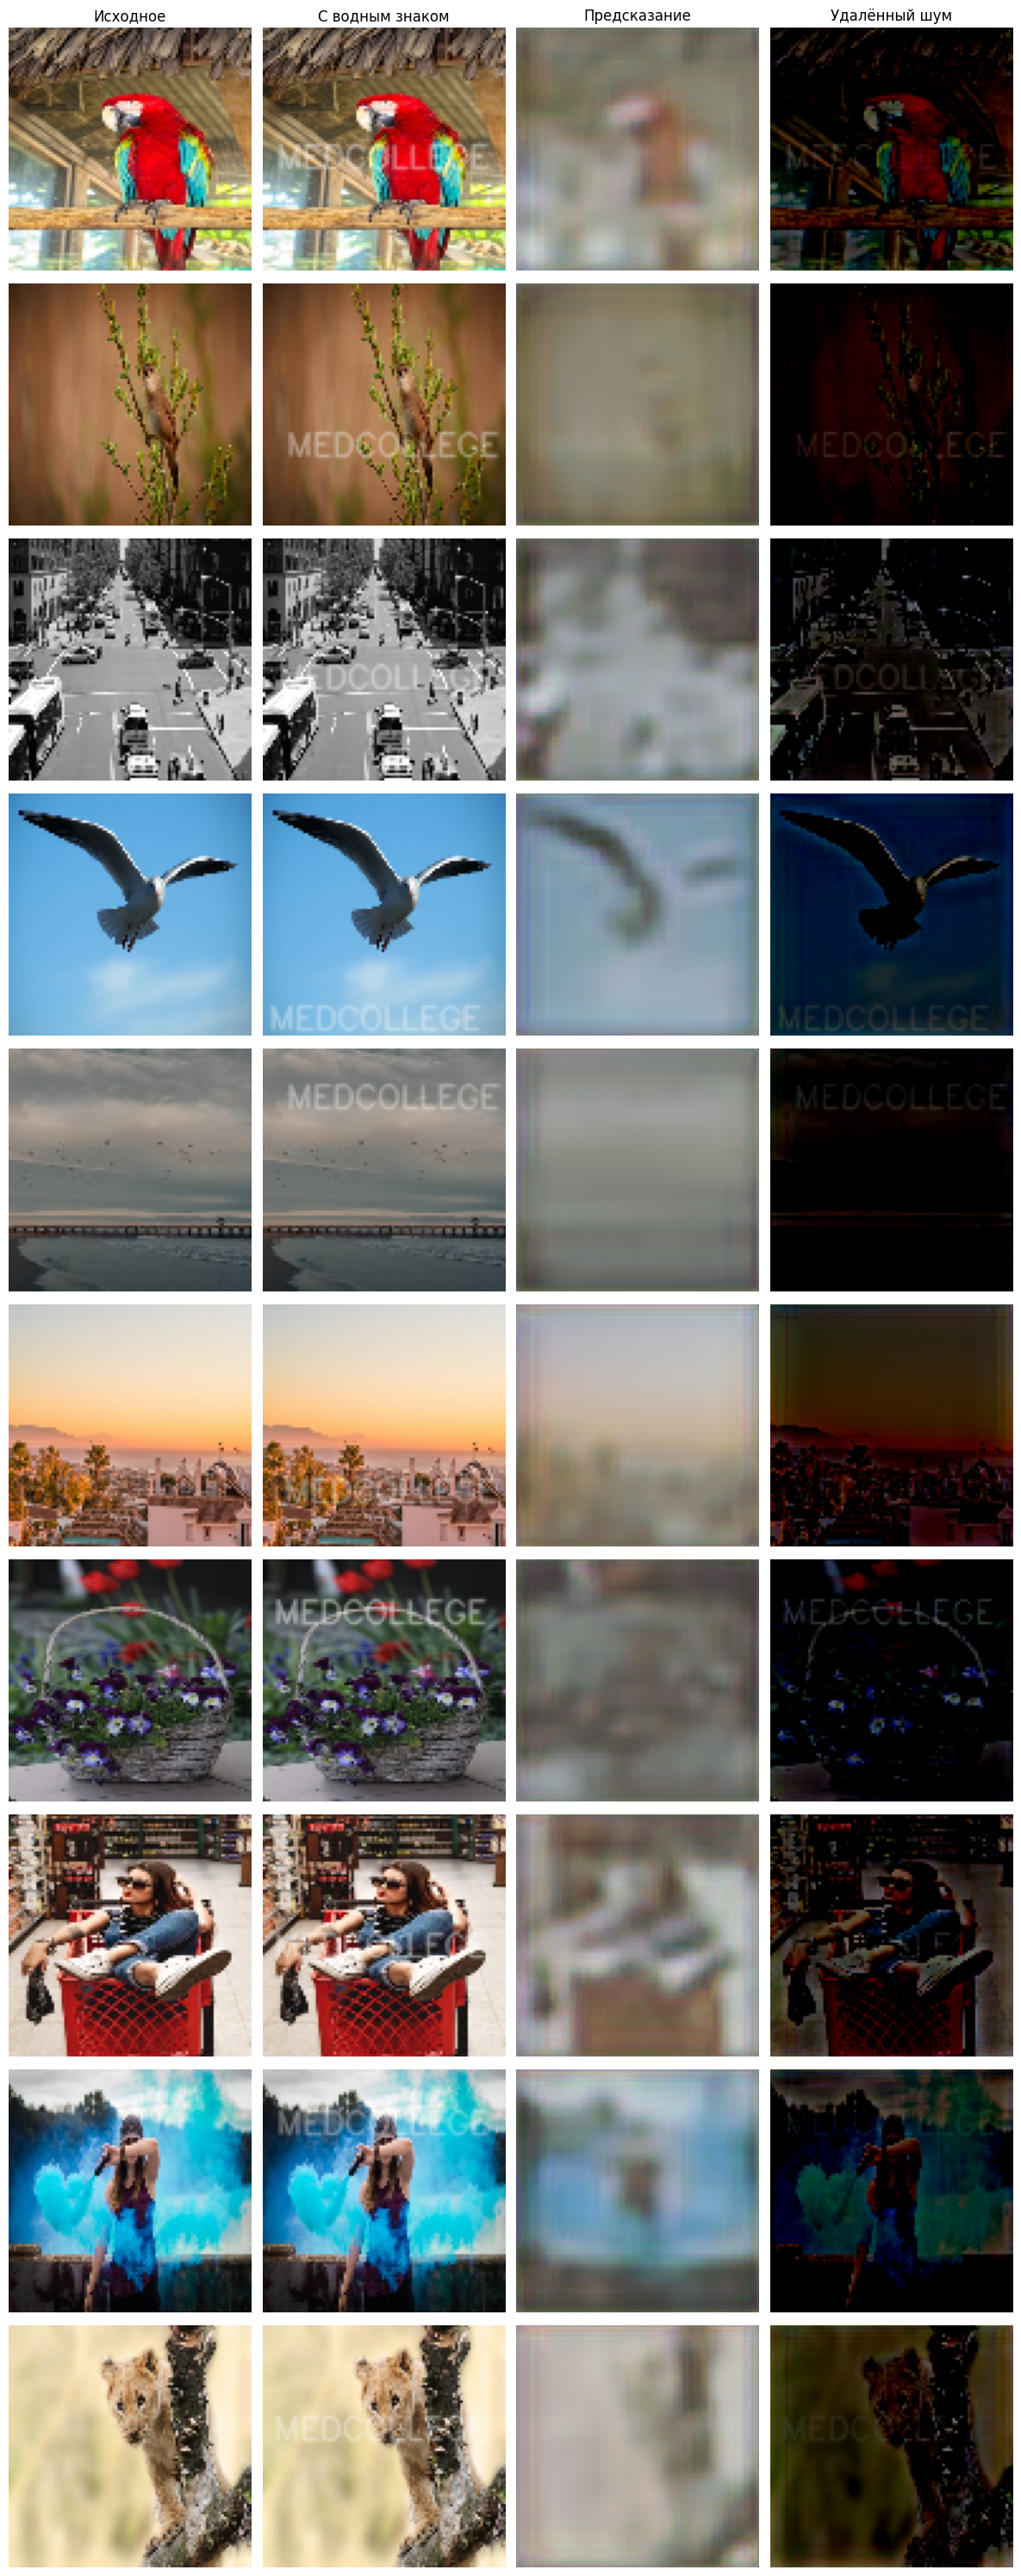

Модель сохранена.


In [1]:
# 1. Импорты

import gc
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv2D,
    Input,
    MaxPooling2D,
    UpSampling2D,
)
from tensorflow.keras.optimizers import Adam

print("TensorFlow:", tf.__version__)



# 2. Фиксируем случайность

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 3. Загрузка датасета

!wget -q \
    https://storage.yandexcloud.net/academy.ai/watermarked.zip \
    -O watermarked.zip

!unzip -qo watermarked.zip -d watermarked

print("Датасет загружен.")



# 4. Пути к изображениям

DATA_DIR = Path("watermarked/wm-nowm")

TRAIN_DIR = (
    DATA_DIR
    / "train"
    / "no-watermark"
)

VALID_DIR = (
    DATA_DIR
    / "valid"
    / "no-watermark"
)

print("Train:", TRAIN_DIR)
print("Valid:", VALID_DIR)
print("Train существует:", TRAIN_DIR.exists())
print("Valid существует:", VALID_DIR.exists())

# 5. Список файлов

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
}

def get_images(folder):

    return sorted([
        path
        for path in folder.rglob("*")
        if path.suffix.lower()
        in IMAGE_EXTENSIONS
    ])


train_paths = get_images(
    TRAIN_DIR
)

valid_paths = get_images(
    VALID_DIR
)

print(
    "Обучающих изображений:",
    len(train_paths)
)

print(
    "Контрольных изображений:",
    len(valid_paths)
)

# 6. Настройки обучения

IMAGE_SIZE = 96
BATCH_SIZE = 8

TRAIN_LIMIT = 600
VALID_LIMIT = 80

STAGES = 3
EPOCHS_PER_STAGE = 4

random.shuffle(
    train_paths
)

random.shuffle(
    valid_paths
)

train_paths = train_paths[
    :TRAIN_LIMIT
]

valid_paths = valid_paths[
    :VALID_LIMIT
]

print(
    "Используем для обучения:",
    len(train_paths)
)

print(
    "Используем для проверки:",
    len(valid_paths)
)



# 7. Загрузка изображения

def load_image(path):

    image = cv2.imread(
        str(path)
    )

    if image is None:
        raise ValueError(
            f"Не удалось открыть {path}"
        )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB,
    )

    image = cv2.resize(
        image,
        (
            IMAGE_SIZE,
            IMAGE_SIZE,
        ),
    )

    image = (
        image.astype(
            np.float32
        )
        / 255.0
    )

    return image



# 8. Аугментация изображений

def augment_image(image):

    height, width = image.shape[:2]

    result = image.copy()

    # 1. Горизонтальное отражение
    if random.random() < 0.5:
        result = cv2.flip(
            result,
            1,
        )

    # 2. Поворот
    if random.random() < 0.5:

        angle = random.uniform(
            -12,
            12,
        )

        matrix = (
            cv2.getRotationMatrix2D(
                (
                    width / 2,
                    height / 2,
                ),
                angle,
                1.0,
            )
        )

        result = cv2.warpAffine(
            result,
            matrix,
            (
                width,
                height,
            ),
            borderMode=(
                cv2.BORDER_REFLECT_101
            ),
        )

    # 3. Сдвиг
    if random.random() < 0.5:

        shift_x = random.randint(
            -7,
            7,
        )

        shift_y = random.randint(
            -7,
            7,
        )

        matrix = np.float32([
            [1, 0, shift_x],
            [0, 1, shift_y],
        ])

        result = cv2.warpAffine(
            result,
            matrix,
            (
                width,
                height,
            ),
            borderMode=(
                cv2.BORDER_REFLECT_101
            ),
        )



# 4. Масштабирование
    if random.random() < 0.5:

        scale = random.uniform(
            0.90,
            1.10,
        )

        matrix = (
            cv2.getRotationMatrix2D(
                (
                    width / 2,
                    height / 2,
                ),
                0,
                scale,
            )
        )

        result = cv2.warpAffine(
            result,
            matrix,
            (
                width,
                height,
            ),
            borderMode=(
                cv2.BORDER_REFLECT_101
            ),
        )



# 5. Изменение яркости
    if random.random() < 0.5:

        brightness = random.uniform(
            -0.08,
            0.08,
        )

        result = (
            result
            + brightness
        )



# 6. Изменение контраста
    if random.random() < 0.5:

        contrast = random.uniform(
            0.85,
            1.15,
        )

        result = (
            result
            * contrast
        )

    return np.clip(
        result,
        0.0,
        1.0,
    )



# 9. Нанесение водного знака

def add_watermark(
    image,
    random_position=True,
):

    base = (
        image
        * 255
    ).astype(
        np.uint8
    )

    overlay = base.copy()

    text = "MEDCOLLEGE"

    font = (
        cv2.FONT_HERSHEY_SIMPLEX
    )

    font_scale = 0.42
    thickness = 1

    text_size = cv2.getTextSize(
        text,
        font,
        font_scale,
        thickness,
    )[0]

    text_width = text_size[0]
    text_height = text_size[1]

    height, width = base.shape[:2]

    if random_position:

        max_x = max(
            1,
            width - text_width - 2,
        )

        x = random.randint(
            1,
            max_x,
        )

        y = random.randint(
            text_height + 2,
            height - 3,
        )

    else:

        x = max(
            1,
            (
                width
                - text_width
            )
            // 2,
        )

        y = height // 2

    cv2.putText(
        overlay,
        text,
        (
            x,
            y,
        ),
        font,
        font_scale,
        (
            255,
            255,
            255,
        ),
        thickness,
        cv2.LINE_AA,
    )

    alpha = random.uniform(
        0.35,
        0.55,
    )

    watermarked = (
        cv2.addWeighted(
            overlay,
            alpha,
            base,
            1 - alpha,
            0,
        )
    )

    return (
        watermarked.astype(
            np.float32
        )
        / 255.0
    )



# 10. Проверка подготовки изображения

sample = load_image(
    train_paths[0]
)

augmented = augment_image(
    sample
)

watermarked = add_watermark(
    augmented
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4),
)

axes[0].imshow(
    sample
)
axes[0].set_title(
    "Исходное"
)

axes[1].imshow(
    augmented
)
axes[1].set_title(
    "После аугментации"
)

axes[2].imshow(
    watermarked
)
axes[2].set_title(
    "С водным знаком"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()



# 11. Генератор данных

class WatermarkSequence(
    tf.keras.utils.Sequence
):

    def __init__(
        self,
        paths,
        batch_size=8,
        augment=False,
        random_watermark=True,
        shuffle=True,
        **kwargs,
    ):

        super().__init__(
            **kwargs
        )

        self.paths = list(
            paths
        )

        self.batch_size = (
            batch_size
        )

        self.augment = augment

        self.random_watermark = (
            random_watermark
        )

        self.shuffle = shuffle

        self.on_epoch_end()

    def __len__(self):

        return int(
            np.ceil(
                len(self.paths)
                / self.batch_size
            )
        )

    def __getitem__(
        self,
        index,
    ):

        start = (
            index
            * self.batch_size
        )

        end = (
            start
            + self.batch_size
        )

        batch_paths = (
            self.paths[
                start:end
            ]
        )

        clean_batch = []
        marked_batch = []

        for path in batch_paths:

            clean = load_image(
                path
            )

            if self.augment:

                clean = augment_image(
                    clean
                )

            marked = add_watermark(
                clean,
                random_position=(
                    self.random_watermark
                ),
            )

            clean_batch.append(
                clean
            )

            marked_batch.append(
                marked
            )

        return (
            np.asarray(
                marked_batch,
                dtype=np.float32,
            ),
            np.asarray(
                clean_batch,
                dtype=np.float32,
            ),
        )

    def on_epoch_end(self):

        if self.shuffle:
            random.shuffle(
                self.paths
            )



# 12. Архитектура автокодировщика

def create_autoencoder():

    inputs = Input(
        shape=(
            IMAGE_SIZE,
            IMAGE_SIZE,
            3,
        )
    )

    # Кодер
    x = Conv2D(
        32,
        3,
        padding="same",
        activation="relu",
    )(inputs)

    x = MaxPooling2D(
        2,
        padding="same",
    )(x)

    x = BatchNormalization()(
        x
    )

    x = Conv2D(
        64,
        3,
        padding="same",
        activation="relu",
    )(x)

    x = MaxPooling2D(
        2,
        padding="same",
    )(x)

    x = BatchNormalization()(
        x
    )

    x = Conv2D(
        128,
        3,
        padding="same",
        activation="relu",
    )(x)

    encoded = MaxPooling2D(
        2,
        padding="same",
        name="latent_space",
    )(x)

    # Декодер
    x = Conv2D(
        128,
        3,
        padding="same",
        activation="relu",
    )(encoded)

    x = UpSampling2D(
        2
    )(x)

    x = BatchNormalization()(
        x
    )

    x = Conv2D(
        64,
        3,
        padding="same",
        activation="relu",
    )(x)

    x = UpSampling2D(
        2
    )(x)

    x = BatchNormalization()(
        x
    )

    x = Conv2D(
        32,
        3,
        padding="same",
        activation="relu",
    )(x)

    x = UpSampling2D(
        2
    )(x)

    outputs = Conv2D(
        3,
        3,
        padding="same",
        activation="sigmoid",
    )(x)

    return Model(
        inputs,
        outputs,
        name="watermark_autoencoder",
    )


autoencoder = create_autoencoder()

autoencoder.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=[
        "mae"
    ],
)

autoencoder.summary()



# 13. Подготовка этапов обучения

training_stages = (
    np.array_split(
        np.asarray(
            train_paths,
            dtype=object,
        ),
        STAGES,
    )
)

for number, stage in enumerate(
    training_stages,
    start=1,
):

    print(
        f"Этап {number}: "
        f"{len(stage)} изображений"
    )



# 14. Контрольная выборка

valid_generator = (
    WatermarkSequence(
        valid_paths,
        batch_size=BATCH_SIZE,
        augment=False,
        random_watermark=False,
        shuffle=False,
    )
)


# 15. Пошаговое обучение

learning_rates = [
    0.001,
    0.0005,
    0.0002,
]

all_loss = []
all_val_loss = []

for stage_number, stage_paths in enumerate(
    training_stages,
    start=1,
):

    learning_rate = (
        learning_rates[
            stage_number - 1
        ]
    )

    autoencoder.optimizer.learning_rate.assign(
        learning_rate
    )

    print()
    print(
        f"Этап {stage_number} "
        f"из {STAGES}"
    )

    print(
        "Изображений:",
        len(stage_paths)
    )

    print(
        "Learning rate:",
        learning_rate
    )

    train_generator = (
        WatermarkSequence(
            stage_paths,
            batch_size=BATCH_SIZE,
            augment=True,
            random_watermark=True,
            shuffle=True,
        )
    )

    history = autoencoder.fit(
        train_generator,
        validation_data=(
            valid_generator
        ),
        epochs=EPOCHS_PER_STAGE,
        verbose=1,
    )

    all_loss.extend(
        history.history[
            "loss"
        ]
    )

    all_val_loss.extend(
        history.history[
            "val_loss"
        ]
    )

    del train_generator
    del history

    gc.collect()

    print(
        f"Этап {stage_number} завершен."
    )



# 16. График обучения

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    all_loss,
    label="Обучающая выборка",
)

plt.plot(
    all_val_loss,
    label="Контрольная выборка",
)

plt.xlabel(
    "Эпоха"
)

plt.ylabel(
    "MSE"
)

plt.title(
    "Ошибка восстановления"
)

plt.legend()
plt.grid(
    alpha=0.3
)

plt.show()



# 17. Подготовка тестовых примеров

TEST_COUNT = 10

test_paths = valid_paths[
    :TEST_COUNT
]

clean_images = []
watermarked_images = []

for path in test_paths:

    clean = load_image(
        path
    )

    marked = add_watermark(
        clean,
        random_position=True,
    )

    clean_images.append(
        clean
    )

    watermarked_images.append(
        marked
    )

clean_images = np.asarray(
    clean_images,
    dtype=np.float32,
)

watermarked_images = np.asarray(
    watermarked_images,
    dtype=np.float32,
)

print(
    "Тестовых изображений:",
    len(clean_images)
)



# 18. Предсказание

predicted_images = (
    autoencoder.predict(
        watermarked_images,
        batch_size=5,
        verbose=1,
    )
)

predicted_images = np.clip(
    predicted_images,
    0.0,
    1.0,
)



# 19. Изображение шума

noise_images = np.clip(
    watermarked_images
    - predicted_images,
    0.0,
    1.0,
)



# 20. Оценка качества

mse = np.mean(
    (
        clean_images
        - predicted_images
    ) ** 2
)

mae = np.mean(
    np.abs(
        clean_images
        - predicted_images
    )
)

print(
    f"MSE: {mse:.6f}"
)

print(
    f"MAE: {mae:.6f}"
)



# 21. Результаты работы модели

fig, axes = plt.subplots(
    TEST_COUNT,
    4,
    figsize=(
        12,
        TEST_COUNT * 3,
    ),
)

titles = [
    "Исходное",
    "С водным знаком",
    "Предсказание",
    "Удалённый шум",
]

for column, title in enumerate(
    titles
):

    axes[0, column].set_title(
        title,
        fontsize=12,
    )


for row in range(
    TEST_COUNT
):

    images = [
        clean_images[row],
        watermarked_images[row],
        predicted_images[row],
        noise_images[row],
    ]

    for column, image in enumerate(
        images
    ):

        axes[
            row,
            column
        ].imshow(
            image
        )

        axes[
            row,
            column
        ].axis(
            "off"
        )


plt.tight_layout()
plt.show()



# 22. Сохранение модели

autoencoder.save(
    "watermark_autoencoder.keras"
)

print(
    "Модель сохранена."
)

